In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import itertools
from scipy.spatial import ConvexHull, Delaunay

# Relaxation Example Figures

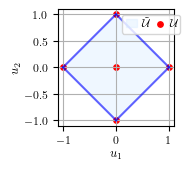

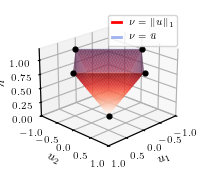

In [ ]:
# Figure size
fig_width = 3.4
fig_height = 1.8

# Font settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.rm": "Times New Roman",
    'text.usetex': True,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7
})

# Define discrete input set U
u_max = 1
U_vertices = np.array([[u_max, 0], [-u_max, 0], [0, u_max], [0, -u_max]])
u_bar = np.max(np.sum(np.abs(U_vertices), axis=1)) # Should be 1 in this config
U_origin = np.zeros((1,2))


# Step size for extra points
step = 0.4

U = np.vstack([U_origin, U_vertices])

# Create figure
fig, ax1 = plt.subplots(figsize=(fig_width, fig_height))
hull = ConvexHull(U_vertices)
ax1.fill(U_vertices[hull.vertices,0], U_vertices[hull.vertices,1],
         color=[0.8,0.9,1.0], alpha=0.3, label=r'$\tilde{\mathcal{U}}$')
for simplex in hull.simplices:
    ax1.plot(U_vertices[simplex, 0], U_vertices[simplex, 1], 'b-', alpha=0.6)
ax1.scatter(U[:,0], U[:,1], c='r', s=15, label=r'$\mathcal{U}$')
ax1.set_xlabel(r'$u_1$', labelpad=2)
ax1.set_ylabel(r'$u_2$', labelpad=2)
ax1.set_aspect('equal')
ax1.grid(True)

ax1.legend(
    loc='upper right',             # position
    fontsize=8,
    bbox_to_anchor=(1.10, 1),     # outside plot
    ncol=2,                        # horizontal layout
    frameon=True,                 # remove box for compactness
    handlelength=1,                # shorten legend marker length
    handletextpad=0.3,             # space between marker and text
    columnspacing=0.5              # space between columns
)


plt.tight_layout()
plt.savefig("2d_set_cross-polytope.pdf", bbox_inches='tight')
plt.show()

# --- 3D Plot ---
fig = plt.figure(figsize=(fig_width, fig_height))
ax2 = fig.add_subplot(111, projection='3d')

# Create a dense grid for smooth surfaces
n_res = 100
u_lin = np.linspace(-u_max, u_max, n_res)
U1, U2 = np.meshgrid(u_lin, u_lin)

# Define the surfaces
mask = (np.abs(U1) + np.abs(U2)) <= u_max
Z_cone = np.abs(U1) + np.abs(U2)
Z_upper = np.full_like(U1, u_bar)

Z_cone_masked = np.where(mask, Z_cone, np.nan)
Z_upper_masked = np.where(mask, Z_upper, np.nan)

# Plotting Surfaces
ax2.plot_surface(U1, U2, Z_cone_masked, cmap='Reds', 
                 alpha=0.7, antialiased=True, edgecolor='none')

ax2.plot_surface(U1, U2, Z_upper_masked, color='royalblue', 
                 alpha=0.3, antialiased=True, edgecolor='none')

z_values = np.sum(np.abs(U), axis=1)
ax2.scatter(U[:, 0], U[:, 1], z_values, 
            color='black', s=12, depthshade=False, zorder=10, label=r'$\mathcal{U}$')

ax2.set_xlabel(r'$u_1$', labelpad=-5)
ax2.set_ylabel(r'$u_2$', labelpad=-5)
ax2.set_zlabel(r'$\nu$', labelpad=-5)

ax2.set_xlim(-u_max, u_max)
ax2.set_ylim(-u_max, u_max)
ax2.set_zlim(0, u_bar + 0.2)

ax2.view_init(elev=22, azim=45)
ax2.tick_params(axis='both', which='major', labelsize=7, pad=0)

# Custom Legend including the discrete points
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label=r'$\nu = \|u\|_1$'),
    Line2D([0], [0], color='royalblue', lw=2, alpha=0.5, label=r'$\nu = \bar{u}$'),
]
ax2.legend(handles=legend_elements, loc='upper right', 
           fontsize=7, frameon=True, handlelength=1)

plt.tight_layout()
plt.savefig("3d_set_final.pdf", bbox_inches='tight')
plt.show()

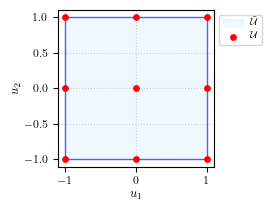

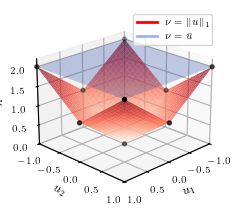

In [ ]:
# Figure size
fig_width = 3.4
fig_height = 2.2

# Font settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.rm": "Times New Roman",
    'text.usetex': True,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7
})

# Define discrete input set U
u_max = 1
m_dim = 2

# Generate the discrete input set U_set
u_values = [-u_max, 0.0, u_max]
U_set = np.array(list(itertools.product(u_values, repeat=m_dim)))

# Compute the Convex Hull for the 2D set
hull = ConvexHull(U_set)

# --- 2D Plot ---
fig, ax1 = plt.subplots(figsize=(fig_width, fig_height))

# Use the hull indices to create the filled polygon
ax1.fill(U_set[hull.vertices, 0], U_set[hull.vertices, 1],
         color=[0.8, 0.9, 1.0], alpha=0.3, label=r'$\tilde{\mathcal{U}}$')

# Plot the edges of the polytope
for simplex in hull.simplices:
    ax1.plot(U_set[simplex, 0], U_set[simplex, 1], 'b-', alpha=0.6, linewidth=1)

# Plot the discrete points
ax1.scatter(U_set[:, 0], U_set[:, 1], c='r', s=15, label=r'$\mathcal{U}$', zorder=3)

ax1.set_xlabel(r'$u_1$', labelpad=2)
ax1.set_ylabel(r'$u_2$', labelpad=2)
ax1.set_aspect('equal')
ax1.grid(True, linestyle=':', alpha=0.6)

ax1.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True)

plt.tight_layout()
plt.savefig("2d_set.pdf", bbox_inches='tight')
plt.show()

# Define the upper bound bar{u} as the max L1 norm of the set
u_bar = np.max(np.sum(np.abs(U_set), axis=1))

# --- 3D Plot: 1-Norm Cone and Top Face ---
fig = plt.figure(figsize=(fig_width, fig_height))
ax = fig.add_subplot(111, projection='3d')

# Create a dense grid
n_res = 60
u_lin = np.linspace(-u_max, u_max, n_res)
U1, U2 = np.meshgrid(u_lin, u_lin)

# The L1-norm Cone (Lower Surface)
Z_cone = np.abs(U1) + np.abs(U2)
cone = ax.plot_surface(U1, U2, Z_cone, cmap='Reds', 
                       alpha=0.7, antialiased=True, edgecolor='none')

# The Top Face (Upper Bound nu = u_bar)
Z_upper = np.full_like(U1, u_bar)
top_face = ax.plot_surface(U1, U2, Z_upper, color='royalblue', 
                           alpha=0.3, antialiased=True, edgecolor='none')

# Discrete Points for reference
ax.scatter(U_set[:,0], U_set[:,1], np.sum(np.abs(U_set), axis=1), 
           color='black', s=8, zorder=20)

# Formatting
ax.set_xlabel(r'$u_1$', labelpad=-5)
ax.set_ylabel(r'$u_2$', labelpad=-5)
ax.set_zlabel(r'$\nu$', labelpad=-5)

# Axis limits
ax.set_zlim(0, u_bar + 0.2)
ax.set_xlim(-u_max, u_max)
ax.set_ylim(-u_max, u_max)

# View angle
ax.view_init(elev=22, azim=45)

# Ticks and layout
ax.tick_params(axis='both', which='major', labelsize=7, pad=0)

legend_elements = [
    Line2D([0], [0], color='red', lw=2, label=r'$\nu = \|u\|_1$'),
    Line2D([0], [0], color='royalblue', lw=2, alpha=0.5, label=r'$\nu = \bar{u}$')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=7, frameon=True)

plt.tight_layout()
plt.savefig("3d_set_with_top.pdf", bbox_inches='tight')
plt.show()